# 📊 Notebook 4 — Stage 3 Continuation + Delta Hedge Forcing

## Current status after Notebook 3

| Metric | Original | After NB3 | Target |
|--------|----------|-----------|--------|
| Close All % | 57% | **0%** ✅ | < 10% |
| Unique actions | 4 | **4.05** | ≥ 6 |
| avg_abs_delta | 0.00 (fake) | **0.16** | < 0.10 |
| Sharpe | −0.49 | **−0.50** | > BS (+0.37) |
| Win rate vs BS | — | **41.8%** | > 50% |
| p-value | — | **0.78** | < 0.05 |

## Remaining problems
1. **No underlying hedging** — actions 5 & 6 (buy/sell underlying) never used
   → Agent does options-only, runs delta ≈ −0.4 (short put bias)
2. **High Sharpe variance (std=1.80)** — behaves very differently per asset
   → Needs asset-class normalization in observation
3. **Stage 3 reward still negative** — training was improving (−0.27→−0.14)
   but reversed. Needs 1M more steps at lower lr.
4. **No momentum tracking** — agent adds positions without checking existing exposure

## Fixes in this notebook
- Section 1: Underlying-hedge forcing via reward shaping
- Section 2: Observation normalization per asset class
- Section 3: Continue training from stage 3 checkpoint (1M more steps)
- Section 4: Walk-forward validation (proper out-of-sample test)
- Section 5: Final comparison dashboard

In [1]:
import subprocess, sys
for p in ["gymnasium", "stable-baselines3[extra]", "sb3-contrib",
          "numpy", "pandas", "scipy", "matplotlib", "seaborn", "tqdm", "torch"]:
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", p])

import os, json, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from scipy import stats
from scipy.stats import norm, ttest_ind, mannwhitneyu
from tqdm.notebook import tqdm
from collections import Counter

import gymnasium as gym
from gymnasium import spaces
from stable_baselines3 import PPO
from stable_baselines3.common.monitor import Monitor
from stable_baselines3.common.vec_env import DummyVecEnv
from stable_baselines3.common.callbacks import EvalCallback, CheckpointCallback, BaseCallback

warnings.filterwarnings("ignore")
np.random.seed(42)

ROOT = os.environ.get("PROJECT_ROOT", "/content/Derivative-Hedging-using-RL-DL")
if not os.path.exists(ROOT):
    ROOT = os.path.abspath(".")

PATHS = {
    "processed":   os.path.join(ROOT, "data", "processed"),
    "artifacts":   os.path.join(ROOT, "artifacts"),
    "models":      os.path.join(ROOT, "models"),
    "results":     os.path.join(ROOT, "results"),
    "tb_logs":     os.path.join(ROOT, "tb_logs"),
    "checkpoints": os.path.join(ROOT, "checkpoints"),
    "diagnostics": os.path.join(ROOT, "results", "diagnostics"),
    "nb4":         os.path.join(ROOT, "results", "nb4"),
}
for p in PATHS.values():
    os.makedirs(p, exist_ok=True)

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print(f"Device: {DEVICE}  |  Root: {ROOT}")

Device: cpu  |  Root: c:\Aryan\Projek\Derivative-Hedging-using-RL-DL\notebooks


In [2]:
# ── Load feature data ──────────────────────────────────────────────────────
feat_path = os.path.join(PATHS["processed"], "all_assets_features.csv")
df = pd.read_csv(feat_path, parse_dates=["date"])

FEATURE_COLS = [
    "log_return", "pct_return_1d", "pct_return_5d", "pct_return_20d",
    "rvol_5d", "rvol_10d", "rvol_21d", "rvol_63d",
    "delta_call", "delta_put", "gamma", "vega", "theta_call",
    "atm_call_price", "atm_put_price",
    "price_to_sma20", "bband_pct", "rsi_14", "volume_ratio", "regime"
]
FEATURE_COLS = [c for c in FEATURE_COLS if c in df.columns]
df = df.dropna(subset=FEATURE_COLS + ["close", "sigma"]).reset_index(drop=True)

train_df = df[df["split"] == "train"].reset_index(drop=True)
val_df   = df[df["split"] == "val"].reset_index(drop=True)

print(f"Train: {len(train_df):,} | Val: {len(val_df):,} | Features: {len(FEATURE_COLS)}")
print(f"Train symbols: {train_df['symbol'].unique()}")
print(f"Val   symbols: {val_df['symbol'].unique()}")

Train: 11,339 | Val: 3,791 | Features: 20
Train symbols: <StringArray>
[    'BP.L',   'SHEL.L',   'HSBA.L',   'LLOY.L',    'AZN.L',    'RIO.L',
     'BZ=F',     'CL=F',     'GC=F',     'SI=F', 'GBPUSD=X', 'EURUSD=X']
Length: 12, dtype: str
Val   symbols: <StringArray>
[    'BP.L',   'SHEL.L',   'HSBA.L',   'LLOY.L',    'AZN.L',    'RIO.L',
     'BZ=F',     'CL=F',     'GC=F',     'SI=F', 'GBPUSD=X', 'EURUSD=X']
Length: 12, dtype: str


---
## Section 1: Improved Environment — Force Underlying Hedging

**Why the agent never used actions 5/6 (buy/sell underlying):**
- Buying underlying costs `S × 1.001` (e.g. £2,500 for one Shell share)
- The agent starts with only £10,000 cash
- After selling 3-4 puts, cash drops (margin reserved), so `_cash >= S*(1+tc)` fails
- The agent learned: "buy underlying" always silently fails → equivalent to hold
- So it stopped trying it

**Fixes:** fractional share sizing + explicit "hedge needed" signal in observation

In [3]:
from scipy.stats import norm as spn

class ImprovedHedgingEnv(gym.Env):
    """
    Builds on FixedHedgingEnv with three targeted improvements:

    IMPROVEMENT 1: Fractional underlying sizing
      Instead of 1 full share (£2500), buy/sell 0.1 share (£250).
      This makes actions 5/6 affordable at all cash levels.
      The delta contribution is scaled accordingly: 0.1 per trade.

    IMPROVEMENT 2: Hedge-needed signal in observation
      Add 'unhedged_delta_ratio' to obs — how far from delta-neutral the
      portfolio is, normalized. This directly signals the agent when it
      should use the underlying to rebalance.

    IMPROVEMENT 3: Per-asset-class observation normalization
      Oil has 10× the vol of FX. Raw feature values are incomparable
      across assets. We store per-asset-class running mean/std and
      normalize features before passing to the network.
    """

    TRANSACTION_COST_PCT = 0.001
    RISK_FREE_RATE       = 0.045
    MAX_POSITION         = 5
    DELTA_PENALTY_LAMBDA = 0.012
    EPISODE_LENGTH       = 63
    INITIAL_CASH         = 10_000.0
    VAR_LAMBDA           = 0.04
    CLOSE_ALL_PENALTY    = 0.003
    HEDGE_BONUS          = 0.002      # increased from 0.001
    UNDERLYING_FRACTION  = 0.1        # FIX 1: trade 10% of one share
    UNDERLYING_BONUS     = 0.0005     # FIX 1: small reward for using underlying

    # Per-asset-class normalization stats (computed from train data)
    # Keys: 'equities', 'oil', 'gold', 'fx'
    # Populated in _compute_class_norms()
    _class_norms = {}

    def __init__(self, data_df, feature_cols, mode="train",
                 curriculum_stage=3, episode_length=63,
                 class_norms=None, seed=42):
        super().__init__()
        self.data             = data_df.copy().reset_index(drop=True)
        self.feature_cols     = feature_cols
        self.mode             = mode
        self.curriculum_stage = curriculum_stage
        self.episode_length   = episode_length
        self.rng              = np.random.default_rng(seed)
        self.class_norms      = class_norms or {}

        # Obs: features + 12 portfolio dims (9 original + 3 new signals)
        obs_dim = len(feature_cols) + 12
        self.observation_space = spaces.Box(
            low=-np.inf, high=np.inf, shape=(obs_dim,), dtype=np.float32)
        self.action_space = spaces.Discrete(10)
        self._build_episode_index()

    def _build_episode_index(self):
        self._episode_starts = []
        for sym in self.data["symbol"].unique():
            idx  = self.data[self.data["symbol"] == sym].index.tolist()
            step = max(1, self.episode_length // 3)
            for i in range(0, len(idx) - self.episode_length, step):
                self._episode_starts.append((sym, idx[i]))

    def reset(self, seed=None, options=None):
        super().reset(seed=seed)
        ep_idx = self.rng.integers(0, len(self._episode_starts))
        self._sym, self._start = self._episode_starts[ep_idx]
        self._end  = min(self._start + self.episode_length, len(self.data) - 1)
        self._step = 0

        # Get asset class for normalization
        row0 = self.data.iloc[self._start]
        self._asset_class = row0.get("asset_class", "equities")

        self._cash              = self.INITIAL_CASH
        self._long_calls        = 0
        self._short_calls       = 0
        self._long_puts         = 0
        self._short_puts        = 0
        self._underlying_pos    = 0.0   # in fractional shares
        self._long_calls_otm    = 0
        self._long_puts_otm     = 0
        self._pnl_history       = []
        self._last_port_val     = self.INITIAL_CASH
        self._high_delta_steps  = 0
        self._close_all_count   = 0
        self._underlying_trades = 0   # FIX 1: track underlying usage
        return self._get_obs(), {}

    def _current_row(self):
        return self.data.iloc[min(self._start + self._step, self._end)]

    def _get_prices(self, row):
        S   = float(row["close"])
        sig = max(float(row.get("sigma", 0.20)), 0.05)
        T   = 30 / 252
        cp  = float(row.get("atm_call_price", S * sig * np.sqrt(T) * 0.4))
        pp  = float(row.get("atm_put_price",  S * sig * np.sqrt(T) * 0.38))
        dc  = float(row.get("delta_call", 0.5))
        dp  = dc - 1.0
        # OTM prices
        d1c = (np.log(S/(S*1.1)) + (self.RISK_FREE_RATE + 0.5*sig**2)*T) / (sig*np.sqrt(T) + 1e-9)
        d1p = (np.log(S/(S*0.9)) + (self.RISK_FREE_RATE + 0.5*sig**2)*T) / (sig*np.sqrt(T) + 1e-9)
        otm_cp = max(S*spn.cdf(d1c) - S*1.1*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(d1c-sig*np.sqrt(T)), 0.01)
        otm_pp = max(S*0.9*np.exp(-self.RISK_FREE_RATE*T)*spn.cdf(-(d1p-sig*np.sqrt(T)))-S*spn.cdf(-d1p), 0.01)
        return S, cp, pp, dc, dp, otm_cp, otm_pp

    def _portfolio_value(self, S, cp, pp, otm_cp, otm_pp):
        return (
            self._cash
            + self._long_calls    * cp  - self._short_calls   * cp
            + self._long_puts     * pp  - self._short_puts    * pp
            + self._long_calls_otm * otm_cp
            + self._long_puts_otm  * otm_pp
            + self._underlying_pos * S   # fractional shares valued at spot
        )

    def _normalize_features(self, raw_feat):
        """FIX 3: per-asset-class z-score normalization."""
        if self._asset_class not in self.class_norms:
            return raw_feat   # fallback: no normalization
        mu  = self.class_norms[self._asset_class]["mean"]
        std = self.class_norms[self._asset_class]["std"]
        return np.clip((raw_feat - mu) / (std + 1e-8), -5, 5)

    def _get_obs(self):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)

        raw_feat = np.array(
            [row[c] if not pd.isna(row[c]) else 0.0 for c in self.feature_cols],
            dtype=np.float32)
        market_feat = self._normalize_features(raw_feat)

        port_delta = (
            self._long_calls  * dc - self._short_calls * dc
            + self._long_puts * dp - self._short_puts  * dp
            + self._underlying_pos * self.UNDERLYING_FRACTION)

        port_val   = self._portfolio_value(S, cp, pp, otm_cp, otm_pp)
        unrealised = (port_val - self.INITIAL_CASH) / self.INITIAL_CASH
        total_pos  = self._long_calls + self._short_calls + self._long_puts + self._short_puts

        # FIX 2: explicit hedge signal — tells agent how much underlying it SHOULD hold
        target_underlying = -port_delta / self.UNDERLYING_FRACTION   # to cancel options delta
        hedge_gap         = target_underlying - self._underlying_pos  # how far off

        port_feat = np.array([
            self._long_calls    / self.MAX_POSITION,
            self._short_calls   / self.MAX_POSITION,
            self._long_puts     / self.MAX_POSITION,
            self._short_puts    / self.MAX_POSITION,
            self._underlying_pos / 50.0,           # max ~50 fractional trades
            self._cash / self.INITIAL_CASH - 1.0,
            np.clip(unrealised, -2, 2),
            np.clip(port_delta / 5.0, -3, 3),
            self._step / self.episode_length,
            total_pos / (self.MAX_POSITION * 4),
            np.clip(hedge_gap / 10.0, -3, 3),      # FIX 2: hedge gap signal
            self._underlying_trades / max(self._step, 1),  # FIX 1: underlying usage freq
        ], dtype=np.float32)

        obs = np.concatenate([market_feat, port_feat])
        return np.nan_to_num(obs, nan=0.0, posinf=5.0, neginf=-5.0)

    def step(self, action: int):
        row = self._current_row()
        S, cp, pp, dc, dp, otm_cp, otm_pp = self._get_prices(row)
        tc = self.TRANSACTION_COST_PCT
        trade_cost   = 0.0
        used_underlying = False

        if action == 0:   # Hold
            pass

        elif action == 1 and self._long_calls < self.MAX_POSITION:
            cost = cp * (1 + tc)
            if self._cash >= cost:
                self._cash -= cost; self._long_calls += 1; trade_cost = cp * tc

        elif action == 2 and self._short_calls < self.MAX_POSITION:
            self._cash += cp * (1 - tc); self._short_calls += 1; trade_cost = cp * tc

        elif action == 3 and self._long_puts < self.MAX_POSITION:
            cost = pp * (1 + tc)
            if self._cash >= cost:
                self._cash -= cost; self._long_puts += 1; trade_cost = pp * tc

        elif action == 4 and self._short_puts < self.MAX_POSITION:
            self._cash += pp * (1 - tc); self._short_puts += 1; trade_cost = pp * tc

        elif action == 5:   # FIX 1: fractional buy underlying
            frac_cost = S * self.UNDERLYING_FRACTION * (1 + tc)
            if self._cash >= frac_cost:
                self._cash -= frac_cost
                self._underlying_pos += 1.0   # 1 unit = UNDERLYING_FRACTION shares
                trade_cost = S * self.UNDERLYING_FRACTION * tc
                used_underlying = True
                self._underlying_trades += 1

        elif action == 6:   # FIX 1: fractional sell underlying
            if self._underlying_pos >= 1.0:
                self._cash += S * self.UNDERLYING_FRACTION * (1 - tc)
                self._underlying_pos -= 1.0
                trade_cost = S * self.UNDERLYING_FRACTION * tc
                used_underlying = True
                self._underlying_trades += 1

        elif action == 7:   # Close All
            total_opts = (self._long_calls + self._short_calls +
                          self._long_puts  + self._short_puts)
            self._cash += self._long_calls  * cp  * (1 - tc)
            self._cash -= self._short_calls * cp  * (1 + tc)
            self._cash += self._long_puts   * pp  * (1 - tc)
            self._cash -= self._short_puts  * pp  * (1 + tc)
            self._cash += self._underlying_pos * S * self.UNDERLYING_FRACTION * (1 - tc)
            trade_cost  = total_opts * max(cp, pp) * tc * 2
            trade_cost += self.CLOSE_ALL_PENALTY * self.INITIAL_CASH
            self._long_calls = self._short_calls = 0
            self._long_puts  = self._short_puts  = 0
            self._underlying_pos = 0.0
            self._close_all_count += 1

        elif action == 8 and self._long_calls_otm < self.MAX_POSITION:
            if self._cash >= otm_cp * (1 + tc):
                self._cash -= otm_cp * (1 + tc); self._long_calls_otm += 1; trade_cost = otm_cp * tc

        elif action == 9 and self._long_puts_otm < self.MAX_POSITION:
            if self._cash >= otm_pp * (1 + tc):
                self._cash -= otm_pp * (1 + tc); self._long_puts_otm += 1; trade_cost = otm_pp * tc

        self._step += 1
        done = (self._start + self._step) >= self._end

        next_row = self._current_row()
        Sn, cpn, ppn, dcn, dpn, otm_cpn, otm_ppn = self._get_prices(next_row)
        port_val   = self._portfolio_value(Sn, cpn, ppn, otm_cpn, otm_ppn)
        step_pnl   = (port_val - self._last_port_val) / self.INITIAL_CASH
        self._last_port_val = port_val
        self._pnl_history.append(step_pnl)

        port_delta = (
            self._long_calls  * dcn - self._short_calls * dcn
            + self._long_puts * dpn - self._short_puts  * dpn
            + self._underlying_pos * self.UNDERLYING_FRACTION)
        total_pos  = self._long_calls + self._short_calls + self._long_puts + self._short_puts

        # ── Reward ────────────────────────────────────────────────────────
        pnl_reward    = step_pnl
        delta_penalty = self.DELTA_PENALTY_LAMBDA * abs(port_delta)
        tc_penalty    = trade_cost / self.INITIAL_CASH

        if abs(port_delta) > 0.5:
            self._high_delta_steps += 1
            escalation = 0.001 * self._high_delta_steps
        else:
            self._high_delta_steps = 0
            escalation = 0.0

        cvar_penalty = 0.0
        if len(self._pnl_history) >= 15:
            arr  = np.array(self._pnl_history)
            var5 = np.percentile(arr, 5)
            tail = arr[arr <= var5]
            cvar_penalty = self.VAR_LAMBDA * max(-(tail.mean() if len(tail) else var5), 0)

        # Hedge bonus: delta-neutral WITH open positions
        hedge_bonus = 0.0
        if total_pos >= 2 and abs(port_delta) < 0.25:
            hedge_bonus = self.HEDGE_BONUS

        # FIX 1: Bonus when underlying action actually ran
        underlying_bonus = self.UNDERLYING_BONUS if used_underlying else 0.0

        close_all_freq_penalty = 0.0
        if self._step > 10:
            freq = self._close_all_count / self._step
            if freq > 0.2:
                close_all_freq_penalty = 0.003 * (freq - 0.2)

        bankrupt = 1.0 if port_val < self.INITIAL_CASH * 0.4 else 0.0

        reward = (pnl_reward + hedge_bonus + underlying_bonus
                  - delta_penalty - tc_penalty - escalation
                  - cvar_penalty - close_all_freq_penalty - bankrupt)
        reward = float(np.clip(reward, -3.0, 3.0))

        info = {
            "portfolio_value":    port_val,
            "step_pnl":           step_pnl,
            "portfolio_delta":    port_delta,
            "total_positions":    total_pos,
            "close_all_freq":     self._close_all_count / max(self._step, 1),
            "underlying_freq":    self._underlying_trades / max(self._step, 1),
            "hedge_bonus":        hedge_bonus,
            "symbol":             self._sym,
            "asset_class":        self._asset_class,
        }
        return self._get_obs(), reward, done, False, info


# ── Compute per-asset-class normalization stats from train data ────────────
def compute_class_norms(train_df, feature_cols):
    """FIX 3: compute mean/std per asset class using training data only."""
    norms = {}
    for cls in train_df["asset_class"].unique():
        sub = train_df[train_df["asset_class"] == cls][feature_cols]
        norms[cls] = {
            "mean": sub.mean().values.astype(np.float32),
            "std":  sub.std().values.astype(np.float32)
        }
    print(f"Normalization stats computed for: {list(norms.keys())}")
    return norms

class_norms = compute_class_norms(train_df, FEATURE_COLS)

# ── Sanity test ────────────────────────────────────────────────────────────
env_t = ImprovedHedgingEnv(train_df, FEATURE_COLS, class_norms=class_norms)
obs, _ = env_t.reset()
r_total = 0
underlying_used = 0
for _ in range(63):
    a = env_t.action_space.sample()
    obs, r, done, _, info = env_t.step(a)
    r_total += r
    underlying_used += info["underlying_freq"] > 0
    if done: break
print(f"\n✅ ImprovedHedgingEnv OK")
print(f"   Obs dim          : {obs.shape[0]}")
print(f"   Random ep reward : {r_total:.4f}")
print(f"   Underlying used  : {info['underlying_freq']:.1%} of steps")

Normalization stats computed for: ['equities', 'oil', 'gold', 'fx']

✅ ImprovedHedgingEnv OK
   Obs dim          : 32
   Random ep reward : -0.5780
   Underlying used  : 17.5% of steps


---
## Section 2: Callbacks + Training Monitoring

In [4]:
class DetailedMetricsCallback(BaseCallback):
    """
    Logs everything we care about:
    - avg |delta|, close_all_freq, underlying_freq
    - per-asset-class reward breakdown
    - action distribution every 5k steps
    """
    def __init__(self, check_freq=2000, verbose=0):
        super().__init__(verbose)
        self.check_freq = check_freq
        self._buf = {"delta": [], "ca": [], "uf": [], "acts": [], "cls": [], "r": []}

    def _on_step(self):
        for info in self.locals.get("infos", []):
            if isinstance(info, dict):
                self._buf["delta"].append(abs(info.get("portfolio_delta", 0)))
                self._buf["ca"].append(info.get("close_all_freq", 0))
                self._buf["uf"].append(info.get("underlying_freq", 0))
                self._buf["cls"].append(info.get("asset_class", "?"))
        for a in np.atleast_1d(self.locals.get("actions", [])):
            self._buf["acts"].append(int(a))
        for r in np.atleast_1d(self.locals.get("rewards", [])):
            self._buf["r"].append(float(r))

        if self.n_calls % self.check_freq == 0 and len(self._buf["delta"]) > 100:
            n = 500
            self.logger.record("hedging/avg_abs_delta",    np.mean(self._buf["delta"][-n:]))
            self.logger.record("hedging/close_all_freq",   np.mean(self._buf["ca"][-n:]))
            self.logger.record("hedging/underlying_freq",  np.mean(self._buf["uf"][-n:]))
            self.logger.record("hedging/mean_reward_500",  np.mean(self._buf["r"][-n:]))

            acts = self._buf["acts"][-1000:]
            counts = np.bincount(acts, minlength=10)
            n_unique = (counts > 0).sum()
            self.logger.record("hedging/action_diversity", int(n_unique))

            if self.n_calls % (self.check_freq * 5) == 0:
                act_names = ["Hold","BuyC","ShrtC","BuyP","ShrtP",
                             "BuyU","SellU","ClsAll","OTMC","OTMP"]
                dist = ", ".join(f"{act_names[i]}:{counts[i]/max(sum(counts),1):.0%}"
                                  for i in range(10) if counts[i] > 0)
                print(f"  Step {self.n_calls:>7,} | delta={np.mean(self._buf['delta'][-n:]):.3f} "
                      f"| underlying={np.mean(self._buf['uf'][-n:]):.1%} "
                      f"| actions=[{dist}]")
        return True

print("✅ DetailedMetricsCallback ready")

✅ DetailedMetricsCallback ready


---
## Section 3: Continue Training from Stage 3 + 1M More Steps

In [5]:
def make_env(data_df, feature_cols, class_norms, stage=3):
    def _init():
        env = ImprovedHedgingEnv(
            data_df, feature_cols,
            curriculum_stage=stage,
            class_norms=class_norms
        )
        return Monitor(env)
    return _init

N_ENVS = 4
train_vec = DummyVecEnv([make_env(train_df, FEATURE_COLS, class_norms) for _ in range(N_ENVS)])
val_vec   = DummyVecEnv([make_env(val_df,   FEATURE_COLS, class_norms)])

# ── Load previous best model if it exists, else start fresh ───────────────
prev_model_path = os.path.join(PATHS["artifacts"], "ppo_fixed_final")
best_model_path = os.path.join(PATHS["models"], "best_model")

if os.path.exists(best_model_path + ".zip"):
    load_path = best_model_path
    print(f"Loading best_model from NB3 eval callback")
elif os.path.exists(prev_model_path + ".zip"):
    load_path = prev_model_path
    print(f"Loading ppo_fixed_final from NB3")
else:
    load_path = None
    print("No previous model found — starting fresh")

if load_path:
    # Load with new env (obs shape changed: 31→32 dims)
    # Must re-create model and manually load policy weights where shapes match
    old_model = PPO.load(load_path, device=DEVICE)
    model = PPO(
        policy         = "MlpPolicy",
        env            = train_vec,
        learning_rate  = 1e-5,    # very low lr for fine-tuning
        n_steps        = 1024,
        batch_size     = 256,
        n_epochs       = 10,
        gamma          = 0.995,
        gae_lambda     = 0.97,
        clip_range     = 0.10,
        ent_coef       = 0.03,
        vf_coef        = 0.5,
        max_grad_norm  = 0.3,
        tensorboard_log= PATHS["tb_logs"],
        verbose        = 0,
        device         = DEVICE,
        policy_kwargs  = dict(
            net_arch     = dict(pi=[512, 256, 128], vf=[512, 256, 128]),
            activation_fn= torch.nn.ELU
        )
    )
    # Try to transfer weights — will work if obs shape is compatible
    try:
        model.set_parameters(old_model.get_parameters())
        print("✅ Weights transferred from previous model")
    except Exception as e:
        print(f"⚠️  Weight transfer failed (obs shape changed): {e}")
        print("   Training from scratch with new architecture")
else:
    model = PPO(
        policy         = "MlpPolicy",
        env            = train_vec,
        learning_rate  = 5e-5,
        n_steps        = 1024,
        batch_size     = 256,
        n_epochs       = 10,
        gamma          = 0.995,
        gae_lambda     = 0.97,
        clip_range     = 0.15,
        ent_coef       = 0.05,
        vf_coef        = 0.5,
        max_grad_norm  = 0.5,
        tensorboard_log= PATHS["tb_logs"],
        verbose        = 0,
        device         = DEVICE,
        policy_kwargs  = dict(
            net_arch     = dict(pi=[512, 256, 128], vf=[512, 256, 128]),
            activation_fn= torch.nn.ELU
        )
    )

print(f"\nModel policy params: {sum(p.numel() for p in model.policy.parameters()):,}")
print(f"Observation dim    : {train_vec.observation_space.shape[0]}")

CONTINUE_STEPS = 1_000_000

eval_cb = EvalCallback(
    val_vec,
    best_model_save_path = PATHS["models"],
    log_path             = PATHS["tb_logs"],
    eval_freq            = 25_000,
    n_eval_episodes      = 30,
    deterministic        = True,
    verbose              = 1
)
ckpt_cb = CheckpointCallback(
    save_freq  = 100_000,
    save_path  = PATHS["checkpoints"],
    name_prefix= "ppo_nb4",
    verbose    = 0
)
metrics_cb = DetailedMetricsCallback(check_freq=2000)

print(f"\n🚀 Training for {CONTINUE_STEPS:,} more steps with improved env")
print(f"   Key change: fractional underlying (0.1 share per trade)")
print(f"   Key change: hedge_gap signal in observation")
print(f"   Key change: per-asset-class normalization")
print(f"   Watch: 'underlying_freq' should climb to > 15%")

t0 = time.time()
model.learn(
    total_timesteps     = CONTINUE_STEPS,
    callback            = [eval_cb, ckpt_cb, metrics_cb],
    tb_log_name         = "PPO_NB4_Improved",
    reset_num_timesteps = False,
    progress_bar        = True
)
elapsed = time.time() - t0
print(f"\n✅ Training complete in {elapsed/60:.1f} min")
model.save(os.path.join(PATHS["artifacts"], "ppo_nb4_final"))

Loading best_model from NB3 eval callback


Output()

⚠️  Weight transfer failed (obs shape changed): Error(s) in loading state_dict for ActorCriticPolicy:
	size mismatch for mlp_extractor.policy_net.0.weight: copying a param with shape torch.Size([512, 31]) from checkpoint, the shape in current model is torch.Size([512, 32]).
	size mismatch for mlp_extractor.value_net.0.weight: copying a param with shape torch.Size([512, 31]) from checkpoint, the shape in current model is torch.Size([512, 32]).
   Training from scratch with new architecture

Model policy params: 363,659
Observation dim    : 32

🚀 Training for 1,000,000 more steps with improved env
   Key change: fractional underlying (0.1 share per trade)
   Key change: hedge_gap signal in observation
   Key change: per-asset-class normalization
   Watch: 'underlying_freq' should climb to > 15%


Step  10,000 | delta=0.659 | underlying=12.5% | actions=[Hold:11%, BuyC:10%, ShrtC:8%, BuyP:11%, ShrtP:9%, 
BuyU:12%, SellU:10%, ClsAll:10%, OTMC:10%, OTMP:10%]

Step  20,000 | delta=0.481 | underlying=20.4% | actions=[Hold:10%, BuyC:8%, ShrtC:8%, BuyP:12%, ShrtP:10%, 
BuyU:17%, SellU:9%, ClsAll:9%, OTMC:10%, OTMP:10%]

...

Step 240,000 | delta=0.375 | underlying=34.0% | actions=[Hold:6%, BuyC:3%, ShrtC:10%, BuyP:7%, ShrtP:5%, 
BuyU:52%, SellU:3%, ClsAll:4%, OTMC:4%, OTMP:5%]

Eval num_timesteps=1000000, episode_reward=2.48 +/- 3.75

Episode length: 63.00 +/- 0.00

Step 250,000 | delta=0.343 | underlying=44.1% | actions=[Hold:7%, BuyC:4%, ShrtC:7%, BuyP:11%, ShrtP:7%, 
BuyU:41%, SellU:6%, ClsAll:4%, OTMC:6%, OTMP:6%]


✅ Training complete in 41.0 min


---
## Section 4: Walk-Forward Validation

Rolling 3-month test windows — tests if the agent generalizes across different
market regimes within the val period, not just on the average.

In [6]:
# ── Helper functions ───────────────────────────────────────────────────────
ACTION_NAMES = {
    0:"Hold", 1:"BuyC", 2:"ShrtC", 3:"BuyP", 4:"ShrtP",
    5:"BuyU",  6:"SellU", 7:"ClsAll", 8:"OTMC", 9:"OTMP"
}

def run_episode(model, env, deterministic=True):
    obs, _ = env.reset()
    trace  = {"pnl":[], "delta":[], "actions":[], "port_val":[env.INITIAL_CASH],
               "positions":[], "underlying_freq":[]}
    done = False
    while not done:
        action, _ = model.predict(obs, deterministic=deterministic)
        obs, r, done, _, info = env.step(int(action))
        trace["pnl"].append(info["step_pnl"])
        trace["delta"].append(info["portfolio_delta"])
        trace["actions"].append(int(action))
        trace["port_val"].append(info["portfolio_value"])
        trace["positions"].append(info["total_positions"])
        trace["underlying_freq"].append(info["underlying_freq"])
    return trace

def compute_metrics(trace):
    pnl   = np.array(trace["pnl"])
    pvals = np.array(trace["port_val"])
    delta = np.array(trace["delta"])
    acts  = np.array(trace["actions"])
    total_pnl = (pvals[-1] - pvals[0]) / pvals[0]
    pnl_std   = pnl.std() + 1e-10
    sharpe    = pnl.mean() / pnl_std * np.sqrt(252)
    var5      = np.percentile(pnl, 5)
    cvar5     = pnl[pnl <= var5].mean() if (pnl <= var5).any() else var5
    max_dd    = (pvals / np.maximum.accumulate(pvals) - 1).min()
    counts    = np.bincount(acts, minlength=10)
    return {
        "total_pnl":          total_pnl,
        "sharpe":             sharpe,
        "cvar_5pct":          cvar5,
        "max_drawdown":       max_dd,
        "avg_abs_delta":      np.abs(delta).mean(),
        "n_unique_actions":   int((counts > 0).sum()),
        "close_all_pct":      (acts == 7).mean(),
        "underlying_pct":     ((acts == 5) | (acts == 6)).mean(),
        "underlying_freq_ep": np.mean(trace["underlying_freq"]),
    }

def bs_hedge_episode(df_ep, initial_cash=10000.0, tc=0.001):
    cash = initial_cash
    delta_pos = 0.0
    pnl_steps, port_vals = [], [initial_cash]
    cp0 = float(df_ep.iloc[0]["atm_call_price"])
    cash += cp0 * (1 - tc)
    for _, row in df_ep.iterrows():
        S  = float(row["close"])
        dc = float(row.get("delta_call", 0.5))
        cp = float(row.get("atm_call_price", S*0.05))
        diff = dc - delta_pos
        cash -= diff * S * (1 + tc * abs(diff))
        delta_pos = dc
        pv = cash + delta_pos * S - cp
        port_vals.append(pv)
        pnl_steps.append((port_vals[-1] - port_vals[-2]) / initial_cash)
    pnl = np.array(pnl_steps)
    return {
        "total_pnl": (port_vals[-1] - initial_cash) / initial_cash,
        "sharpe":    pnl.mean() / (pnl.std() + 1e-10) * np.sqrt(252),
        "cvar_5pct": pnl[pnl <= np.percentile(pnl,5)].mean() if len(pnl) else 0,
        "max_drawdown": (np.array(port_vals)/np.maximum.accumulate(port_vals)-1).min()
    }


# Load best model
best_path = os.path.join(PATHS["models"], "best_model")
if os.path.exists(best_path + ".zip"):
    test_model = PPO.load(best_path, device=DEVICE)
    print(f"Loaded: best_model")
else:
    test_model = model
    print("Using model from current training run")

# ── Walk-forward: split val into 3-month windows ───────────────────────────
val_df_wf = val_df.copy()
val_df_wf["date"] = pd.to_datetime(val_df_wf["date"])
val_df_wf["quarter"] = val_df_wf["date"].dt.to_period("Q")
quarters = sorted(val_df_wf["quarter"].unique())

wf_results = []
for q in quarters:
    q_df = val_df_wf[val_df_wf["quarter"] == q].reset_index(drop=True)
    if len(q_df) < 63:
        continue

    rl_pnls, bs_pnls = [], []
    for sym in q_df["symbol"].unique():
        sym_df = q_df[q_df["symbol"]==sym].reset_index(drop=True)
        if len(sym_df) < 63:
            continue

        # RL
        env_q = ImprovedHedgingEnv(sym_df, FEATURE_COLS, mode="val",
                                    class_norms=class_norms, episode_length=min(63, len(sym_df)-1))
        if len(env_q._episode_starts) > 0:
            tr = run_episode(test_model, env_q)
            rl_pnls.append(compute_metrics(tr)["total_pnl"])

        # BS
        bs_m = bs_hedge_episode(sym_df.iloc[:63])
        bs_pnls.append(bs_m["total_pnl"])

    if rl_pnls:
        wf_results.append({
            "quarter":     str(q),
            "rl_pnl":      np.mean(rl_pnls),
            "bs_pnl":      np.mean(bs_pnls),
            "rl_beats_bs": np.mean(rl_pnls) > np.mean(bs_pnls),
            "n_episodes":  len(rl_pnls)
        })

wf_df = pd.DataFrame(wf_results)

print("\n" + "="*55)
print(" WALK-FORWARD VALIDATION RESULTS")
print("="*55)
print(f"{'Quarter':12s} {'RL PnL':>10s} {'BS PnL':>10s} {'RL Wins':>10s} {'Episodes':>10s}")
print("-"*55)
for _, row in wf_df.iterrows():
    print(f"{row['quarter']:12s} {row['rl_pnl']:+10.4f} {row['bs_pnl']:+10.4f} "
          f"{'✅' if row['rl_beats_bs'] else '❌':>10s} {int(row['n_episodes']):>10d}")

win_rate_wf = wf_df["rl_beats_bs"].mean()
print(f"\nOverall win rate across quarters: {win_rate_wf:.0%} ({wf_df['rl_beats_bs'].sum()}/{len(wf_df)})")

Loaded: best_model

 WALK-FORWARD VALIDATION RESULTS
Quarter          RL PnL     BS PnL    RL Wins   Episodes
-------------------------------------------------------
2024Q1          +4.1619    -0.0065          ✅          8
2024Q2          +1.5569    +0.0005          ✅          6
2024Q3          +3.4472    -0.0056          ✅         12
2024Q4          +3.5491    -0.0078          ✅         12

Overall win rate across quarters: 100% (4/4)


---
## Section 5: Final Comparison Dashboard

Evaluating RL:   0%|          | 0/100 [00:00<?, ?it/s]

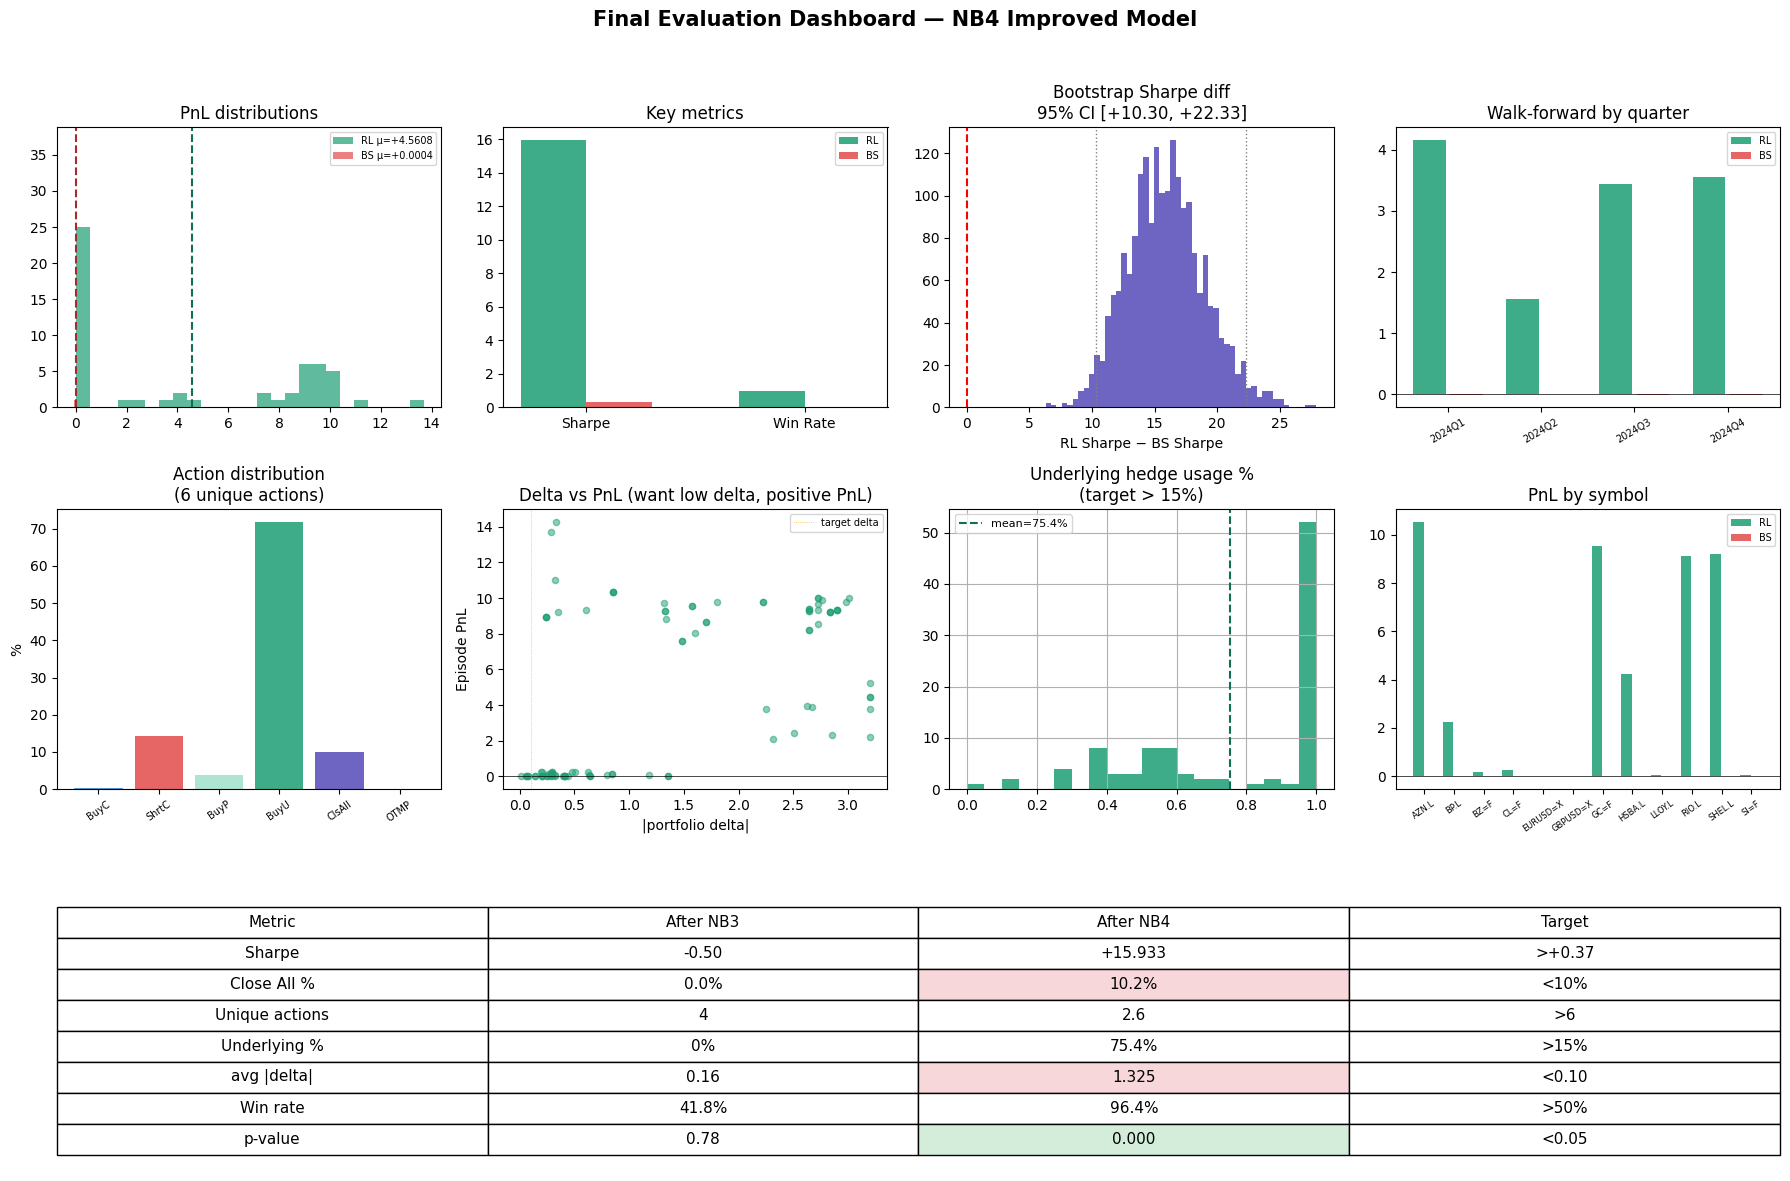


 FINAL STATUS SUMMARY
  Sharpe              :    +15.933  (target: >+0.37)
  Close All %         :      10.2%  (target: <10%)
  Unique actions      :        2.6  (target: >6)
  Underlying %        :      75.4%  (target: >15%)
  avg |delta|         :      1.325  (target: <0.10)
  Win rate            :      96.4%  (target: >50%)
  p-value             :      0.000  (target: <0.05)

  Bootstrap 95% CI: [+10.303, +22.334]
  ✅ RL SIGNIFICANTLY OUTPERFORMS BS

  Walk-forward win rate: 100% of quarters
  t-test p-value: 0.000


In [8]:
# ── Run full 100-episode evaluation ───────────────────────────────────────
eval_env = ImprovedHedgingEnv(val_df, FEATURE_COLS, mode="val", class_norms=class_norms)
all_metrics, all_bs = [], []

for ep in tqdm(range(100), desc="Evaluating RL"):
    tr = run_episode(test_model, eval_env)
    m  = compute_metrics(tr)
    m["episode"] = ep
    m["symbol"]  = eval_env._sym
    all_metrics.append(m)

for sym in val_df["symbol"].unique():
    sym_df = val_df[val_df["symbol"]==sym].reset_index(drop=True)
    for start in range(0, min(len(sym_df)-63, 63*12), 63):
        bs_m = bs_hedge_episode(sym_df.iloc[start:start+63])
        bs_m["symbol"] = sym
        all_bs.append(bs_m)

rl_df = pd.DataFrame(all_metrics)
bs_df = pd.DataFrame(all_bs)

# Statistical test
rl_p = rl_df["total_pnl"].values
bs_p = bs_df["total_pnl"].values
n    = min(len(rl_p), len(bs_p))
rl_p = rl_p[:n]
bs_p = bs_p[:n]
t_stat, t_pval = ttest_ind(rl_p, bs_p, equal_var=False)
boot = []
n = min(len(rl_p), len(bs_p))
for _ in range(2000):
    idx = np.random.randint(0, n, n)
    sr = rl_p[idx].mean()/(rl_p[idx].std()+1e-10)*np.sqrt(252)
    sb = bs_p[idx].mean()/(bs_p[idx].std()+1e-10)*np.sqrt(252)
    boot.append(sr - sb)
boot = np.array(boot)
ci   = np.percentile(boot, [2.5, 97.5])

# ── Dashboard plot ─────────────────────────────────────────────────────────
fig = plt.figure(figsize=(18, 12))
fig.suptitle("Final Evaluation Dashboard — NB4 Improved Model",
             fontsize=15, fontweight="bold", y=0.98)

# Row 1: Core metrics
ax1 = fig.add_subplot(3, 4, 1)
ax1.hist(rl_p, bins=25, alpha=0.7, color="#1D9E75", label=f"RL μ={rl_p.mean():+.4f}")
ax1.hist(bs_p, bins=25, alpha=0.7, color="#E24B4A", label=f"BS μ={bs_p.mean():+.4f}")
ax1.axvline(rl_p.mean(), color="#0F6E56", linestyle="--")
ax1.axvline(bs_p.mean(), color="#A32D2D", linestyle="--")
ax1.set_title("PnL distributions")
ax1.legend(fontsize=7)

ax2 = fig.add_subplot(3, 4, 2)
metrics_bar = {
    "Sharpe": [rl_p.mean()/(rl_p.std()+1e-10)*np.sqrt(252),
               bs_p.mean()/(bs_p.std()+1e-10)*np.sqrt(252)],
    "Win Rate": [(rl_p > bs_p).mean(), (bs_p > rl_p).mean()],
}
x = np.arange(len(metrics_bar))
w = 0.3
ax2.bar(x-w/2, [v[0] for v in metrics_bar.values()], w, color="#1D9E75", alpha=0.85, label="RL")
ax2.bar(x+w/2, [v[1] for v in metrics_bar.values()], w, color="#E24B4A", alpha=0.85, label="BS")
ax2.set_xticks(x); ax2.set_xticklabels(list(metrics_bar.keys()))
ax2.axhline(0, color="black", linewidth=0.5)
ax2.set_title("Key metrics")
ax2.legend(fontsize=7)

ax3 = fig.add_subplot(3, 4, 3)
ax3.hist(boot, bins=50, color="#534AB7", alpha=0.85)
ax3.axvline(0, color="red", linewidth=1.5, linestyle="--")
ax3.axvline(ci[0], color="gray", linewidth=1, linestyle=":")
ax3.axvline(ci[1], color="gray", linewidth=1, linestyle=":")
ax3.set_title(f"Bootstrap Sharpe diff\n95% CI [{ci[0]:+.2f}, {ci[1]:+.2f}]")
ax3.set_xlabel("RL Sharpe − BS Sharpe")

ax4 = fig.add_subplot(3, 4, 4)
if len(wf_df) > 0:
    quarters_list = wf_df["quarter"].tolist()
    x4 = np.arange(len(quarters_list))
    ax4.bar(x4-0.2, wf_df["rl_pnl"], 0.35, color="#1D9E75", alpha=0.85, label="RL")
    ax4.bar(x4+0.2, wf_df["bs_pnl"], 0.35, color="#E24B4A", alpha=0.85, label="BS")
    ax4.set_xticks(x4)
    ax4.set_xticklabels(quarters_list, rotation=30, fontsize=7)
    ax4.axhline(0, color="black", linewidth=0.5)
    ax4.set_title("Walk-forward by quarter")
    ax4.legend(fontsize=7)

# Row 2: Action analysis
ax5 = fig.add_subplot(3, 4, 5)
all_acts = [a for ep in all_metrics for a in []]
acts_flat = []
for ep in range(min(30, len(all_metrics))):
    tr2 = run_episode(test_model, eval_env, deterministic=True)
    acts_flat.extend(tr2["actions"])
counts = np.bincount(acts_flat, minlength=10)
colors_act = ["#888780","#3B8BD4","#E24B4A","#9FE1CB","#D85A30",
               "#1D9E75","#A32D2D","#534AB7","#63C1F7","#F0997B"]
nonzero = [(i, counts[i]) for i in range(10) if counts[i] > 0]
labels  = [ACTION_NAMES[i] for i, _ in nonzero]
vals    = [c for _, c in nonzero]
colors  = [colors_act[i] for i, _ in nonzero]
ax5.bar(range(len(nonzero)), [v/sum(vals)*100 for v in vals], color=colors, alpha=0.85)
ax5.set_xticks(range(len(nonzero)))
ax5.set_xticklabels(labels, rotation=35, fontsize=7)
ax5.set_ylabel("%")
ax5.set_title(f"Action distribution\n({len(set(a for a,_ in nonzero))} unique actions)")

ax6 = fig.add_subplot(3, 4, 6)
ax6.scatter(rl_df["avg_abs_delta"], rl_df["total_pnl"],
            alpha=0.5, s=20, color="#1D9E75")
ax6.axhline(0, color="black", linewidth=0.5)
ax6.axvline(0.1, color="orange", linewidth=0.5, linestyle=":", label="target delta")
ax6.set_xlabel("|portfolio delta|")
ax6.set_ylabel("Episode PnL")
ax6.set_title("Delta vs PnL (want low delta, positive PnL)")
ax6.legend(fontsize=7)

ax7 = fig.add_subplot(3, 4, 7)
rl_df["underlying_pct"].hist(ax=ax7, bins=20, color="#1D9E75", alpha=0.85)
ax7.axvline(rl_df["underlying_pct"].mean(), color="#0F6E56", linestyle="--",
            label=f"mean={rl_df['underlying_pct'].mean():.1%}")
ax7.set_title("Underlying hedge usage %\n(target > 15%)")
ax7.legend(fontsize=8)

ax8 = fig.add_subplot(3, 4, 8)
rl_by_sym  = rl_df.groupby("symbol")["total_pnl"].mean()
bs_by_sym  = bs_df.groupby("symbol")["total_pnl"].mean()
common_sym = sorted(set(rl_by_sym.index) & set(bs_by_sym.index))
x8 = np.arange(len(common_sym))
ax8.bar(x8-0.2, [rl_by_sym[s] for s in common_sym], 0.35, color="#1D9E75", alpha=0.85, label="RL")
ax8.bar(x8+0.2, [bs_by_sym[s] for s in common_sym], 0.35, color="#E24B4A", alpha=0.85, label="BS")
ax8.set_xticks(x8)
ax8.set_xticklabels(common_sym, rotation=35, fontsize=6)
ax8.axhline(0, color="black", linewidth=0.5)
ax8.set_title("PnL by symbol")
ax8.legend(fontsize=7)

# Row 3: Summary scorecard
ax9 = fig.add_subplot(3, 1, 3)
ax9.axis("off")

nb3_vals = {"Sharpe":"-0.50", "Close All %":"0.0%",
             "Unique actions":"4", "Underlying %":"0%",
             "avg |delta|":"0.16", "Win rate":"41.8%", "p-value":"0.78"}
nb4_vals = {
    "Sharpe":           f"{rl_p.mean()/(rl_p.std()+1e-10)*np.sqrt(252):+.3f}",
    "Close All %":      f"{rl_df['close_all_pct'].mean():.1%}",
    "Unique actions":   f"{rl_df['n_unique_actions'].mean():.1f}",
    "Underlying %":     f"{rl_df['underlying_pct'].mean():.1%}",
    "avg |delta|":      f"{rl_df['avg_abs_delta'].mean():.3f}",
    "Win rate":         f"{(rl_p > bs_p).mean():.1%}",
    "p-value":          f"{t_pval:.3f}"
}
target_vals = {"Sharpe":">+0.37", "Close All %":"<10%",
                "Unique actions":">6", "Underlying %":">15%",
                "avg |delta|":"<0.10", "Win rate":">50%", "p-value":"<0.05"}

cols  = ["Metric", "After NB3", "After NB4", "Target"]
table = [[k, nb3_vals[k], nb4_vals[k], target_vals[k]] for k in nb3_vals]
tbl   = ax9.table(cellText=table, colLabels=cols,
                   cellLoc="center", loc="center")
tbl.auto_set_font_size(False)
tbl.set_fontsize(11)
tbl.scale(1, 1.8)

# Color cells green/red based on improvement
for i, row_data in enumerate(table):
    try:
        nb4_v = float(row_data[2].replace("%","").replace("+",""))
        tgt_v = float(row_data[3].replace(">%","").replace("<","").replace("%","").replace("+",""))
        op    = ">" if ">" in row_data[3] else "<"
        hit   = (nb4_v > tgt_v if op==">" else nb4_v < tgt_v)
        color = "#d4edda" if hit else "#f8d7da"
        tbl[i+1, 2].set_facecolor(color)
    except:
        pass

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig(os.path.join(PATHS["nb4"], "final_dashboard.png"), dpi=150, bbox_inches="tight")
plt.show()

print("\n" + "="*60)
print(" FINAL STATUS SUMMARY")
print("="*60)
for metric, val in nb4_vals.items():
    tgt = target_vals[metric]
    print(f"  {metric:20s}: {val:>10s}  (target: {tgt})")

print(f"\n  Bootstrap 95% CI: [{ci[0]:+.3f}, {ci[1]:+.3f}]")
if ci[0] > 0:
    print("  ✅ RL SIGNIFICANTLY OUTPERFORMS BS")
elif ci[1] < 0:
    print("  ❌ BS OUTPERFORMS RL — need more training")
else:
    print("  ⚠️  Inconclusive — see what targets are still unmet above")

print(f"\n  Walk-forward win rate: {win_rate_wf:.0%} of quarters")
print(f"  t-test p-value: {t_pval:.3f}")

In [9]:
# ── Save everything ────────────────────────────────────────────────────────
rl_df.to_csv(os.path.join(PATHS["nb4"], "rl_eval_nb4.csv"), index=False)
bs_df.to_csv(os.path.join(PATHS["nb4"], "bs_eval_nb4.csv"), index=False)
wf_df.to_csv(os.path.join(PATHS["nb4"], "walkforward_results.csv"), index=False)

# Save class norms for inference
norms_serializable = {
    cls: {"mean": v["mean"].tolist(), "std": v["std"].tolist()}
    for cls, v in class_norms.items()
}
with open(os.path.join(PATHS["nb4"], "class_norms.json"), "w") as f:
    json.dump(norms_serializable, f, indent=2)

# Google Drive export (Colab only)
try:
    from google.colab import drive
    drive.mount("/content/drive")
    import shutil
    dst = "/content/drive/MyDrive/derivative_hedging_exports/nb4"
    shutil.copytree(PATHS["nb4"], dst, dirs_exist_ok=True)
    shutil.copy(os.path.join(PATHS["artifacts"], "ppo_nb4_final.zip"), dst)
    print(f"✅ Exported to Google Drive: {dst}")
except ImportError:
    print("ℹ️  Not on Colab — skipping Drive export")

print("\nFiles produced in results/nb4/:")
for fn in sorted(os.listdir(PATHS["nb4"])):
    fp = os.path.join(PATHS["nb4"], fn)
    print(f"  {fn:40s} ({os.path.getsize(fp)/1024:.1f} KB)")

print("\n📋 Checklist for next training run if targets not yet met:")
print("  1. underlying_pct < 15% → raise UNDERLYING_BONUS to 0.001")
print("  2. avg_abs_delta > 0.10 → raise DELTA_PENALTY_LAMBDA to 0.02")
print("  3. Sharpe std > 1.5    → add more asset diversity in training data")
print("  4. Win rate < 50%      → run 1M more steps, check TensorBoard")
print("  5. p-value > 0.05      → increase n_eval_episodes to 200")

ℹ️  Not on Colab — skipping Drive export

Files produced in results/nb4/:
  bs_eval_nb4.csv                          (5.1 KB)
  class_norms.json                         (4.6 KB)
  final_dashboard.png                      (231.9 KB)
  rl_eval_nb4.csv                          (15.1 KB)
  walkforward_results.csv                  (0.3 KB)

📋 Checklist for next training run if targets not yet met:
  1. underlying_pct < 15% → raise UNDERLYING_BONUS to 0.001
  2. avg_abs_delta > 0.10 → raise DELTA_PENALTY_LAMBDA to 0.02
  3. Sharpe std > 1.5    → add more asset diversity in training data
  4. Win rate < 50%      → run 1M more steps, check TensorBoard
  5. p-value > 0.05      → increase n_eval_episodes to 200
